In this notebook, you will be guided through a complete, end-to-end workflow for **training, testing, evaluating, and selecting the best Prophet model** for time series forecasting. The goal is to provide a clean, repeatable, and extensible structure that both agents and data scientists can follow to build high-quality forecasting pipelines.

---

##  Dataset Overview

The dataset represents **monthly demand for hardware products**. Each row corresponds to one month of demand for a specific product. The key fields include:

* **`unique_id`** the identifier for each individual time series
* **`ds`** timestamp column at monthly granularity
* **`y`** the target variable representing monthly product demand

* **Additional categorical and continuous features** used as regressors:

  * `product_type`
  * `region`
  * `unit_cost`
  * `unit_installation_cost`
* **profile_cluster** variable
* profile_cluster is generated with the following rule: `profile_cluster` is equal to `profile` and where `profile` == 'regular' then it is substituted by the cluster value.

---

##  Modeling Framework

All forecasting models in this notebook are built using **Prophet** (from Meta/Facebook):
[https://facebook.github.io/prophet/](https://facebook.github.io/prophet/)

Prophet provides:

* Decomposable time series model (trend + seasonality + holidays + regressors)
* Automatic changepoint detection
* Robust to missing data and outliers
* Support for custom seasonalities and external regressors
* Uncertainty intervals

---
##  Model Variants Compared

We evaluate three Prophet configurations to explore how different settings affect performance:

1. **Default model** — Prophet with default parameters
2. **Linear growth model** — Prophet with `growth='linear'` and custom changepoint settings
3. **Logistic growth model** — Prophet with `growth='logistic'` using data-driven cap/floor

This comparison helps illustrate how growth type and flexibility choices affect accuracy and stability.
These model variants are first trained as individual models per series on the whole training set and then trained again by profile_cluster.

---
##  Adding Regressors

Continuous exogenous features are added as Prophet regressors using `add_regressor()`. Features are analyzed and grouped as:
- static features (excluded from regressors since they don't vary over time per series)
- time-varying numeric features (added as regressors)

---
## Training by profile_cluster
The model variants are trained per series on the whole training set and then trained again by profile_cluster. Results are compared.

## Rolling Evaluation to Avoid Data Leakage

All evaluation in this notebook is performed using **rolling-origin train-test splits**, ensuring that:

* Models never train on future data
* Each forecasting window simulates real operational forecasting
* Time-ordered leakage is avoided
* Model performance is stable across multiple backtests

# Implementation

## Load Packages and Configuration

Load the required packages. In Fabric, we use inline configuration instead of loading from external config files.

In [1]:
import os
from pathlib import Path

# Data elaboration functions
import numpy as np
import pandas as pd
from dateutil.relativedelta import relativedelta
import datetime
import holidays as h
from functools import reduce

# Prophet
from prophet import Prophet

# MLflow for tracking
import mlflow

# Scikit-Learn
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Plots
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter

# Spark for Fabric
from pyspark.sql import SparkSession

# Suppress Prophet info logs
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

print("Packages loaded successfully!")

c:\Users\mabellani\.conda\envs\all-purpose-time-series-forecasting\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Packages loaded successfully!


# Setup

## Configuration Parameters

Defined inline for Fabric compatibility.

In [2]:
training_start_date = '2024-01-01'
training_end_date = '2025-01-06'
forecast_start_date = '2025-01-13'
forecast_end_date = '2025-05-20'

In [6]:
# Time series configuration (inline - previously from config.yaml)
date_var = 'ds'
date_format = '%Y-%m-%d'
id = 'product_name'
unique_id = 'STORE_LOCATION_ID'
list_unique_id = [unique_id, date_var]
frequency = 'W-MON'
y = 'TOTAL_NET_SALES'
  
selection_metric = 'MAE'

# Fabric Lakehouse configuration
LAKEHOUSE_NAME = "ts_forecasting"

# Input table name
INPUT_TABLE_NAME = "df_final"

# Lakehouse table name for profile data
PROFILE_CLUSTER_TABLE_NAME = "df_profiling_clustering"

# Lakehouse table name for feature data
FEATURE_TABLE_NAME = "df_features"

root_path = Path.cwd().parent.parent

LOCAL_FOLDER = "supermarket_net_sales"  # Local folder for fallback storage

print(f"Configuration loaded:")
print(f"  - Date variable: {date_var}")
print(f"  - Target variable: {y}")
print(f"  - Unique ID: {unique_id}")
print(f"  - Frequency: {frequency}")
print(f"  - Training start date: {training_start_date}")
print(f"  - Training end date: {training_end_date}")
print("root_path: ", root_path)

Configuration loaded:
  - Date variable: ds
  - Target variable: TOTAL_NET_SALES
  - Unique ID: STORE_LOCATION_ID
  - Frequency: W-MON
  - Training start date: 2024-01-01
  - Training end date: 2025-01-06
root_path:  c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator


# Load Data

## Load Feature Data from Lakehouse

Load the feature-engineered data from the Fabric Lakehouse table (previously saved from notebook 05 FeatureEngineering).

In [7]:
# Load data from Lakehouse table
try:
    df = spark.read.table(f'{LAKEHOUSE_NAME}.{FEATURE_TABLE_NAME}').toPandas()
except:
    print("\u274c Failed to load data from Lakehouse table. Loading from local parquet file.")
    df = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{FEATURE_TABLE_NAME}.parquet")
print(f"\u2705 Loaded {len(df)} rows")

df.head()

❌ Failed to load data from Lakehouse table. Loading from local parquet file.
✅ Loaded 4800 rows


,STORE_LOCATION_ID,ds,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,profile_cluster,lag1,lag2,rolling_mean_lag1_window_size3,rolling_std_lag1_window_size3,rolling_mean_lag2_window_size6,rolling_std_lag2_window_size6,year,month,week
0,1,2023-05-22,658506.242658,32653,2,0,1,1,0,0,...,1.0,683644.663227,669678.533134,656202.922622,36116.968510,615395.394403,49546.824149,2023,5,21
1,1,2023-05-29,653460.798201,32653,2,0,1,1,0,0,...,1.0,658506.242658,683644.663227,670609.813006,12595.058905,642200.363419,28461.222971,2023,5,22
2,1,2023-06-05,636980.378958,32653,2,0,1,1,0,0,...,1.0,653460.798201,658506.242658,665203.901362,16168.191026,648613.988548,26748.872726,2023,6,23
3,1,2023-06-12,668240.373924,32653,2,0,1,1,0,0,...,1.0,636980.378958,653460.798201,649649.139939,11257.764256,653655.829742,23677.441861,2023,6,24
4,1,2023-06-19,616229.163786,32653,2,0,1,1,0,0,...,1.0,668240.373924,636980.378958,652893.850361,15637.707432,652926.031280,24194.104414,2023,6,25


## Check dtypes

In [8]:
print("\u2705 Dtypes adjusted")
df.dtypes

✅ Dtypes adjusted


STORE_LOCATION_ID                          int64
ds                                datetime64[ns]
TOTAL_NET_SALES                          float64
STORE_SELLING_AREA_SQFT                    int64
NEARBY_COMPETITOR_STORE_COUNT              int64
COMPETITOR_PREMIUM_A_PRESENT               int64
COMPETITOR_DISCOUNT_A_PRESENT              int64
COMPETITOR_WAREHOUSE_A_PRESENT             int64
COMPETITOR_PREMIUM_B_PRESENT               int64
COMPETITOR_DISCOUNT_B_PRESENT              int64
HAS_COMPETITOR_IN_TRADE_AREA               int64
STORE_COUNT_IN_POSTAL_AREA                 int64
IS_SOLE_STORE_IN_POSTAL_AREA               int64
MARKET_SHARE_AREA_POSTAL                 float64
BASELINE_WEEKLY_SALES                    float64
STORE_ARCHETYPE                         category
REGION                                  category
profile_cluster                         category
lag1                                     float64
lag2                                     float64
rolling_mean_lag1_wi

## Add profiling and clustering data and generate profile_cluster column

In [9]:
# Load data from Lakehouse table
if 'profile_cluster' not in df.columns:
    try:
        df_profile_cluster = spark.read.table(f'{LAKEHOUSE_NAME}.{PROFILE_CLUSTER_TABLE_NAME}').toPandas()
    except:
        print("Failed to load data from Lakehouse table. Loading from local parquet file.")
        df_profile_cluster = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{PROFILE_CLUSTER_TABLE_NAME.split('.')[-1]}.parquet")

    print(f"\u2705 Loaded {len(df_profile_cluster)} rows")

    # Merge df with df_cluster on the profile_cluster column
    df = df.merge(df_profile_cluster[['profile_cluster', unique_id]], on=unique_id, how='left')
else:
    print("profile_cluster column already exists in df, skipping merge.")
    
df.head()

profile_cluster column already exists in df, skipping merge.


,STORE_LOCATION_ID,ds,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,profile_cluster,lag1,lag2,rolling_mean_lag1_window_size3,rolling_std_lag1_window_size3,rolling_mean_lag2_window_size6,rolling_std_lag2_window_size6,year,month,week
0,1,2023-05-22,658506.242658,32653,2,0,1,1,0,0,...,1.0,683644.663227,669678.533134,656202.922622,36116.968510,615395.394403,49546.824149,2023,5,21
1,1,2023-05-29,653460.798201,32653,2,0,1,1,0,0,...,1.0,658506.242658,683644.663227,670609.813006,12595.058905,642200.363419,28461.222971,2023,5,22
2,1,2023-06-05,636980.378958,32653,2,0,1,1,0,0,...,1.0,653460.798201,658506.242658,665203.901362,16168.191026,648613.988548,26748.872726,2023,6,23
3,1,2023-06-12,668240.373924,32653,2,0,1,1,0,0,...,1.0,636980.378958,653460.798201,649649.139939,11257.764256,653655.829742,23677.441861,2023,6,24
4,1,2023-06-19,616229.163786,32653,2,0,1,1,0,0,...,1.0,668240.373924,636980.378958,652893.850361,15637.707432,652926.031280,24194.104414,2023,6,25


## Set training start and end date

In [10]:
training_start_date = pd.to_datetime(training_start_date)
training_end_date = pd.to_datetime(training_end_date)
forecast_start_date = pd.to_datetime(forecast_start_date)
forecast_end_date = pd.to_datetime(forecast_end_date)

# Checks
if forecast_start_date >= forecast_end_date:
    raise ValueError("OOS start date must be before OOS end date.")
if forecast_start_date <= training_start_date:
    raise ValueError("OOS start date must be after training start date.")
if forecast_start_date <= training_end_date:
    raise ValueError("OOS start date must be after training end date.")

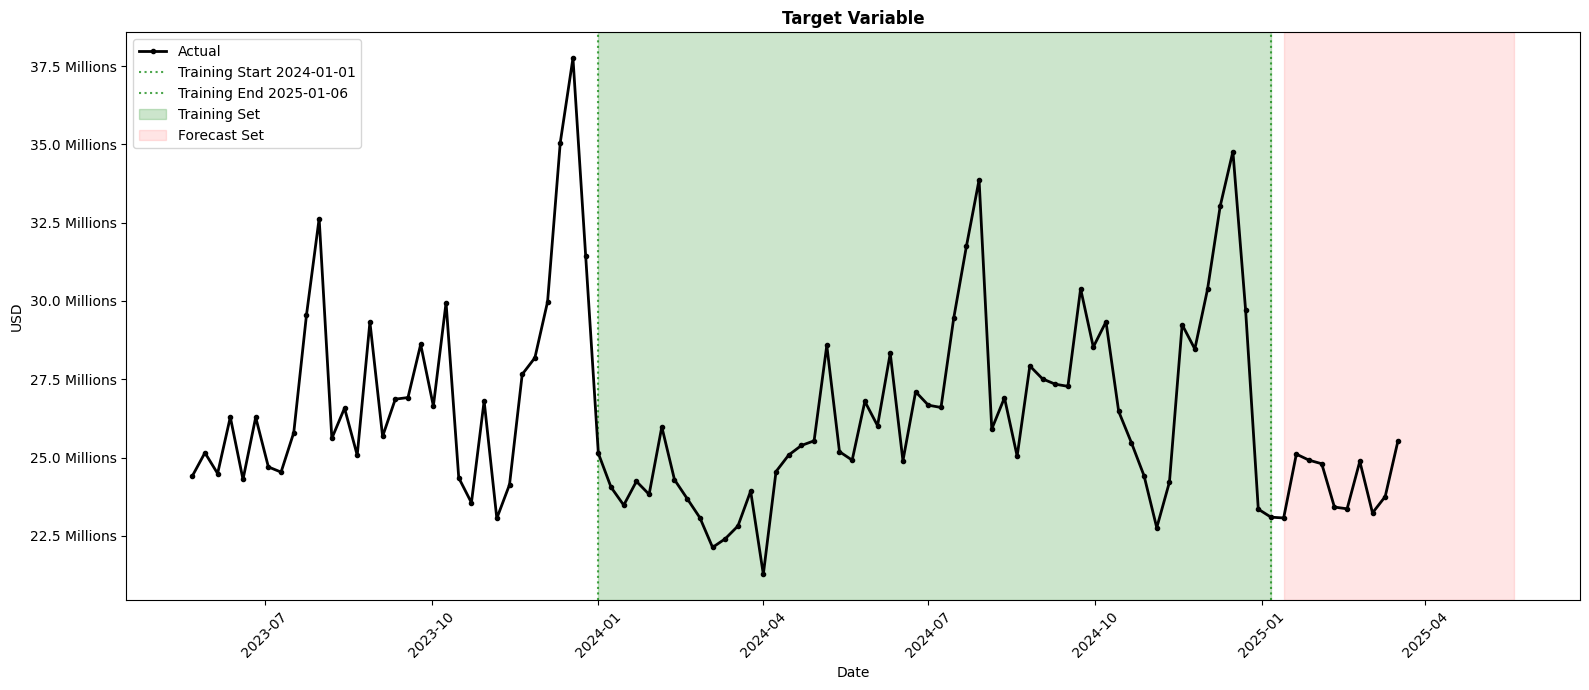

In [11]:
df_to_plot = pd.pivot_table(df.drop_duplicates(), index=[date_var], values=[y], aggfunc='sum', fill_value=np.nan).reset_index()

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(df_to_plot[date_var], df_to_plot[y],
        color='black', linewidth=2, marker='o', markersize=3,
        label='Actual', zorder=5)
ax.axvline(x=training_start_date, color='green', linestyle=':', alpha=0.7, label=f'Training Start {training_start_date.date()}')
ax.axvline(x=training_end_date, color='green', linestyle=':', alpha=0.7, label=f'Training End {training_end_date.date()}')
ax.axvspan(training_start_date, training_end_date, color='green', alpha=0.2, label='Training Set')
ax.axvspan(forecast_start_date, forecast_end_date, color='red', alpha=0.1, label='Forecast Set')
ax.set_title(f'Target Variable', fontsize=12, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('USD')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f} Millions'))
plt.xticks(rotation=45); plt.tight_layout()

# Helper Functions

In [12]:
def get_static_cols(df, id_col, exclude_cols=None):
    """
    Returns columns that are constant within each unique_id (static covariates).
    """
    if exclude_cols is None:
        exclude_cols = []
    
    candidate_cols = [c for c in df.columns if c not in [id_col, 'ds'] + exclude_cols]
    
    static = []
    non_static = []
    for col in candidate_cols:
        n_unique_per_id = df.groupby(id_col)[col].nunique()
        if (n_unique_per_id <= 1).all():
            static.append(col)
        else:
            non_static.append(col)
    
    return static, non_static

In [13]:
def compute_all_metrics(rolling_results, df, id_col="unique_id", ds_col="ds", y_col="y"):
    """
    Join actuals from df into rolling_results, then compute
    WMAPE, MAE, RMSE for every model column starting with 'y_hat_'.
    """
    df = df.copy()
    df[ds_col] = pd.to_datetime(df[ds_col])
    rolling_results = rolling_results.copy()
    rolling_results[ds_col] = pd.to_datetime(rolling_results[ds_col])

    # Join actuals
    merged = rolling_results.merge(
        df[[id_col, ds_col, y_col]],
        on=[id_col, ds_col],
        how="left"
    )

    # Identify model prediction columns
    pred_cols = [c for c in merged.columns if c.startswith("y_hat_")]

    metrics_list = []
    actuals = merged[y_col].astype(float)

    for col in pred_cols:
        preds = merged[col].astype(float)
        mask = actuals.notna() & preds.notna()
        act = actuals[mask]
        pred = preds[mask]

        errors = np.abs(act - pred)
        squared = (act - pred)**2

        wmape = errors.sum() / np.abs(act).sum() if np.abs(act).sum() > 0 else np.nan
        mae = errors.mean()
        rmse = np.sqrt(squared.mean())

        metrics_list.append({
            "model": col,
            "WMAPE": wmape,
            "MAE": mae,
            "RMSE": rmse
        })

    return pd.DataFrame(metrics_list).sort_values("WMAPE")

# Prophet Model Functions

In [14]:
def build_prophet_model(variant="default", cap=None, floor=None):
    """
    Build a Prophet model based on the variant name.
    
    Variants:
    - 'default': Prophet with default parameters
    - 'linear': Prophet with linear growth and tuned changepoint settings
    - 'logistic': Prophet with logistic growth (requires cap/floor)
    """
    if variant == "default":
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
        )
    elif variant == "linear":
        model = Prophet(
            growth='linear',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.1,
            n_changepoints=25,
        )
    elif variant == "logistic":
        model = Prophet(
            growth='logistic',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.05,
        )
    else:
        raise ValueError(f"Unknown variant: {variant}")
    
    return model

In [15]:
def train_prophet_single_series(
    series_df,
    variant="default",
    regressor_cols=None,
    forecast_periods=1,
    frequency="W-MON",
):
    """
    Train a Prophet model on a single time series and return forecasts.
    
    Parameters:
    -----------
    series_df : pd.DataFrame
        DataFrame with 'ds', 'y' columns and optionally regressor columns.
    variant : str
        Prophet model variant ('default', 'linear', 'logistic').
    regressor_cols : list
        List of regressor column names to add.
    forecast_periods : int
        Number of periods to forecast.
    frequency : str
        Frequency string for future dataframe.
    
    Returns:
    --------
    pd.DataFrame with 'ds' and 'yhat' columns.
    """
    if regressor_cols is None:
        regressor_cols = []
    
    # Prepare training data for Prophet
    train_data = series_df[['ds', 'y'] + regressor_cols].copy()
    train_data = train_data.dropna(subset=['y'])
    
    # Compute cap/floor for logistic growth
    cap = None
    floor = None
    if variant == "logistic":
        cap = train_data['y'].max() * 1.5
        floor = max(0, train_data['y'].min() * 0.5)
        train_data['cap'] = cap
        train_data['floor'] = floor
    
    # Build model
    model = build_prophet_model(variant=variant, cap=cap, floor=floor)
    
    # Add regressors
    for col in regressor_cols:
        model.add_regressor(col)
    
    # Fit
    model.fit(train_data)
    
    # Create future dataframe
    future = model.make_future_dataframe(periods=forecast_periods, freq=frequency)
    
    # Add cap/floor for logistic
    if variant == "logistic":
        future['cap'] = cap
        future['floor'] = floor
    
    # Add regressor values to future dataframe
    if regressor_cols:
        # Merge regressor values from original data
        all_data = series_df[['ds'] + regressor_cols].copy()
        future = future.merge(all_data, on='ds', how='left')
        # Forward-fill missing regressor values for future periods
        future[regressor_cols] = future[regressor_cols].ffill()
        # Back-fill any remaining NaN
        future[regressor_cols] = future[regressor_cols].bfill()
    
    # Predict
    forecast = model.predict(future)
    
    return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

In [16]:
def rolling_train_and_predict_prophet_oos(
    df,
    regressor_cols,
    eval_dates,
    training_end_date,
    forecast_end_date,
    freq="W-MON",
    id_col="unique_id",
    ds_col="ds",
    y_col="y",
):
    """
    Performs rolling-origin forecasting using Prophet for each series.
    Evaluates three Prophet model variants: default, linear, logistic.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Full dataframe with all series.
    regressor_cols : list
        Columns to use as external regressors in Prophet.
    eval_dates : list
        List of evaluation date strings.
    training_end_date : pd.Timestamp
        End of the training window.
    forecast_end_date : pd.Timestamp
        End of the forecast window.
    freq : str
        Frequency of the time series.
    id_col : str
        Column name for series identifier.
    ds_col : str
        Column name for date.
    y_col : str
        Column name for target variable.
    
    Returns:
    --------
    pd.DataFrame with columns: id_col, ds_col, y_hat_default, y_hat_linear, y_hat_logistic
    """
    df = df.copy()
    df[ds_col] = pd.to_datetime(df[ds_col])
    
    print("Evaluation dates:", eval_dates)
    print("Max train date:", training_end_date)
    print("Forecast end date:", forecast_end_date)
    
    variants = ["default", "linear", "logistic"]
    series_ids = df[id_col].unique()
    
    all_forecasts = None
    
    for variant in variants:
        with mlflow.start_run(
            run_name=f"prophet_{variant}",
            nested=True,
            tags={"variant": variant},
        ) as parent_run:
            print(f"\n{'='*60}")
            print(f"Prophet variant: {variant}")
            print(f"{'='*60}")
            
            rolling_forecasts = []
            
            for date in eval_dates:
                pred_ts = pd.to_datetime(date)
                
                if pred_ts <= training_end_date:
                    in_sample = True
                    n = 1
                else:
                    in_sample = False
                    future_dates = pd.date_range(start=pred_ts, end=pd.to_datetime(forecast_end_date), freq=freq)
                    n = len(future_dates)
                
                print(f"\n  Date: {date} | {'in-sample' if in_sample else f'OOS ({n} periods)'}")
                
                for sid in series_ids:
                    series_data = df[df[id_col] == sid].copy()
                    train_data = series_data[series_data[ds_col] < pred_ts].copy()
                    
                    if len(train_data) < 4:
                        continue
                    
                    # Prepare Prophet-format dataframe
                    prophet_df = train_data.rename(columns={y_col: 'y'})[
                        ['ds', 'y'] + [c for c in regressor_cols if c in train_data.columns]
                    ].copy()
                    
                    # Full series for regressor values
                    full_series = series_data.rename(columns={y_col: 'y'})[
                        ['ds', 'y'] + [c for c in regressor_cols if c in series_data.columns]
                    ].copy()
                    
                    # Filter regressors to numeric only
                    valid_regressors = [
                        c for c in regressor_cols 
                        if c in prophet_df.columns 
                        and pd.api.types.is_numeric_dtype(prophet_df[c])
                        and prophet_df[c].notna().sum() > 0
                    ]
                    
                    try:
                        forecast = train_prophet_single_series(
                            series_df=full_series,
                            variant=variant,
                            regressor_cols=valid_regressors,
                            forecast_periods=n,
                            frequency=freq,
                        )
                        
                        # Extract only the forecast dates we need
                        if in_sample:
                            fcst_dates = forecast[forecast['ds'] == pred_ts]
                        else:
                            fcst_dates = forecast[forecast['ds'] >= pred_ts]
                        
                        if len(fcst_dates) > 0:
                            result = fcst_dates[['ds', 'yhat']].copy()
                            result[id_col] = sid
                            rolling_forecasts.append(result)
                    except Exception as e:
                        # Skip series that fail (e.g., insufficient data)
                        pass
            
            if rolling_forecasts:
                variant_forecasts = pd.concat(rolling_forecasts, ignore_index=True)
                variant_forecasts = variant_forecasts.drop_duplicates(subset=[id_col, 'ds'], keep='first')
                col_name = f"y_hat_{variant}"
                variant_forecasts = variant_forecasts.rename(columns={'yhat': col_name})
                
                # Compute metrics
                eval_results = df[[id_col, ds_col, y_col]].merge(
                    variant_forecasts, on=[id_col, ds_col], how='inner'
                )
                if len(eval_results) > 0:
                    y_true = eval_results[y_col].astype(float)
                    y_pred = eval_results[col_name].astype(float)
                    mask = y_true.notna() & y_pred.notna()
                    
                    rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
                    mae = mean_absolute_error(y_true[mask], y_pred[mask])
                    print(f"  Variant '{variant}': RMSE={rmse:,.0f}, MAE={mae:,.0f}")
                    mlflow.log_metric(f'rmse_{col_name}', rmse)
                    mlflow.log_metric(f'mae_{col_name}', mae)
                
                mlflow.log_param("variant", variant)
                mlflow.log_param("training_end_date", str(training_end_date))
                
                if all_forecasts is None:
                    all_forecasts = variant_forecasts[[id_col, 'ds', col_name]].copy()
                else:
                    all_forecasts = all_forecasts.merge(
                        variant_forecasts[[id_col, 'ds', col_name]],
                        on=[id_col, 'ds'],
                        how='outer',
                    )
    
    return all_forecasts

# Prepare Data for Prophet

In [17]:
df = df.copy()
freq = frequency
id_col = unique_id
ds_col = 'ds'
y_col = y
df[ds_col] = pd.to_datetime(df[ds_col])

eval_date_training = pd.date_range(start=training_start_date, end=training_end_date, freq=frequency)
eval_date_oos = pd.date_range(start=forecast_start_date, end=forecast_end_date, freq=frequency)
eval_dates = eval_date_training.strftime(date_format).tolist() + eval_date_oos.strftime(date_format).tolist()

print("Evaluation dates:", eval_dates)
print("Forecast end date:", forecast_end_date)
print("Frequency:", frequency)

Evaluation dates: ['2024-01-01', '2024-01-08', '2024-01-15', '2024-01-22', '2024-01-29', '2024-02-05', '2024-02-12', '2024-02-19', '2024-02-26', '2024-03-04', '2024-03-11', '2024-03-18', '2024-03-25', '2024-04-01', '2024-04-08', '2024-04-15', '2024-04-22', '2024-04-29', '2024-05-06', '2024-05-13', '2024-05-20', '2024-05-27', '2024-06-03', '2024-06-10', '2024-06-17', '2024-06-24', '2024-07-01', '2024-07-08', '2024-07-15', '2024-07-22', '2024-07-29', '2024-08-05', '2024-08-12', '2024-08-19', '2024-08-26', '2024-09-02', '2024-09-09', '2024-09-16', '2024-09-23', '2024-09-30', '2024-10-07', '2024-10-14', '2024-10-21', '2024-10-28', '2024-11-04', '2024-11-11', '2024-11-18', '2024-11-25', '2024-12-02', '2024-12-09', '2024-12-16', '2024-12-23', '2024-12-30', '2025-01-06', '2025-01-13', '2025-01-20', '2025-01-27', '2025-02-03', '2025-02-10', '2025-02-17', '2025-02-24', '2025-03-03', '2025-03-10', '2025-03-17', '2025-03-24', '2025-03-31', '2025-04-07', '2025-04-14', '2025-04-21', '2025-04-28', '

## Remove pre-computed rolling/lag features

Prophet handles its own trend and seasonality decomposition, so pre-computed lag/rolling features are not needed.

In [18]:
# Identify columns starting with 'lag' or 'rolling_'
lag_cols = [c for c in df.columns if c.startswith("lag")]
rolling_cols = [c for c in df.columns if c.startswith("rolling_")]

print(f"lag columns ({len(lag_cols)}): {lag_cols}")
print(f"rolling columns ({len(rolling_cols)}): {rolling_cols}")

rolling_lag_cols = lag_cols + rolling_cols

# Remove pre-computed lag/rolling features
cols_to_drop = [c for c in df.columns if c in rolling_lag_cols]
if cols_to_drop:
    print(f"Dropping pre-computed rolling features: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)

lag columns (2): ['lag1', 'lag2']
rolling columns (4): ['rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6']
Dropping pre-computed rolling features: ['lag1', 'lag2', 'rolling_mean_lag1_window_size3', 'rolling_std_lag1_window_size3', 'rolling_mean_lag2_window_size6', 'rolling_std_lag2_window_size6']


In [19]:
# Identify static and non-static features
static_cols, non_static_cols = get_static_cols(df, unique_id, exclude_cols=[y])

print(f"\u2705 Static columns ({len(static_cols)}): {static_cols}")
print(f"\nNon-static columns ({len(non_static_cols)}): {non_static_cols}")

# For Prophet, regressors must be numeric and time-varying
regressor_cols = [
    c for c in non_static_cols 
    if c != 'profile_cluster'
    and c not in ['ds', unique_id, y]
    and pd.api.types.is_numeric_dtype(df[c])
]

print(f"\nRegressor columns for Prophet ({len(regressor_cols)}): {regressor_cols}")

✅ Static columns (15): ['STORE_SELLING_AREA_SQFT', 'NEARBY_COMPETITOR_STORE_COUNT', 'COMPETITOR_PREMIUM_A_PRESENT', 'COMPETITOR_DISCOUNT_A_PRESENT', 'COMPETITOR_WAREHOUSE_A_PRESENT', 'COMPETITOR_PREMIUM_B_PRESENT', 'COMPETITOR_DISCOUNT_B_PRESENT', 'HAS_COMPETITOR_IN_TRADE_AREA', 'STORE_COUNT_IN_POSTAL_AREA', 'IS_SOLE_STORE_IN_POSTAL_AREA', 'MARKET_SHARE_AREA_POSTAL', 'BASELINE_WEEKLY_SALES', 'STORE_ARCHETYPE', 'REGION', 'profile_cluster']

Non-static columns (3): ['year', 'month', 'week']

Regressor columns for Prophet (3): ['year', 'month', 'week']


# Workflow Step-by-Step

## Single Series Example

Demonstrate Prophet training on a single series with the 'default' variant before running the full pipeline.

Example series: 1
Training rows: 86
Date range: 2023-05-22 to 2025-01-06


12:04:03 - cmdstanpy - INFO - Chain [1] start processing
12:04:07 - cmdstanpy - INFO - Chain [1] done processing


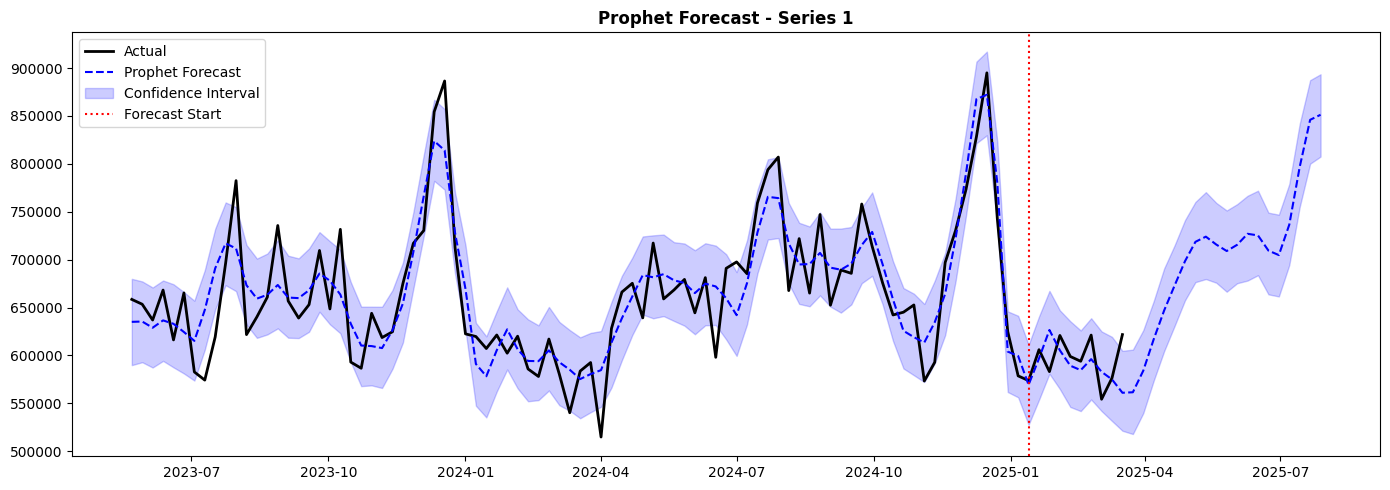

In [20]:
# Pick the first series for demonstration
example_id = df[unique_id].unique()[0]
example_data = df[df[unique_id] == example_id].copy()

# Prepare Prophet-format data
prophet_example = example_data.rename(columns={y: 'y'})[['ds', 'y'] + regressor_cols].copy()

# Train on data before forecast start
train_example = prophet_example[prophet_example['ds'] < forecast_start_date].copy()

print(f"Example series: {example_id}")
print(f"Training rows: {len(train_example)}")
print(f"Date range: {train_example['ds'].min().date()} to {train_example['ds'].max().date()}")

# Filter valid regressors
valid_regressors_example = [
    c for c in regressor_cols 
    if pd.api.types.is_numeric_dtype(train_example[c])
    and train_example[c].notna().sum() > 0
]

# Train and forecast
n_forecast = len(pd.date_range(start=forecast_start_date, end=forecast_end_date, freq=frequency))
forecast_example = train_prophet_single_series(
    series_df=prophet_example,
    variant="default",
    regressor_cols=valid_regressors_example,
    forecast_periods=n_forecast,
    frequency=frequency,
)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(example_data['ds'], example_data[y], 'k-', linewidth=2, label='Actual')
ax.plot(forecast_example['ds'], forecast_example['yhat'], 'b--', linewidth=1.5, label='Prophet Forecast')
ax.fill_between(
    forecast_example['ds'], 
    forecast_example['yhat_lower'], 
    forecast_example['yhat_upper'],
    alpha=0.2, color='blue', label='Confidence Interval'
)
ax.axvline(x=forecast_start_date, color='red', linestyle=':', label='Forecast Start')
ax.set_title(f'Prophet Forecast - Series {example_id}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Train Overall Model (All Series)

Train Prophet for all series across all evaluation dates using rolling-origin evaluation with three model variants.

In [ ]:
mlflow.set_experiment(experiment_name="prophet_rolling_oos_evaluation")

all_forecasts = rolling_train_and_predict_prophet_oos(
    df,
    regressor_cols=regressor_cols,
    eval_dates=eval_dates,
    training_end_date=training_end_date,
    forecast_end_date=forecast_end_date,
    freq=frequency,
    id_col=unique_id,
    ds_col='ds',
    y_col=y,
)

print(f"\n\u2705 Total forecast rows: {len(all_forecasts)}")
all_forecasts.head()

c:\Users\mabellani\.conda\envs\all-purpose-time-series-forecasting\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2026/06/07 12:04:20 INFO mlflow.tracking.fluent: Experiment with name 'prophet_rolling_oos_evaluation' does not exist. Creating a new experiment.


Evaluation dates: ['2024-01-01', '2024-01-08', '2024-01-15', '2024-01-22', '2024-01-29', '2024-02-05', '2024-02-12', '2024-02-19', '2024-02-26', '2024-03-04', '2024-03-11', '2024-03-18', '2024-03-25', '2024-04-01', '2024-04-08', '2024-04-15', '2024-04-22', '2024-04-29', '2024-05-06', '2024-05-13', '2024-05-20', '2024-05-27', '2024-06-03', '2024-06-10', '2024-06-17', '2024-06-24', '2024-07-01', '2024-07-08', '2024-07-15', '2024-07-22', '2024-07-29', '2024-08-05', '2024-08-12', '2024-08-19', '2024-08-26', '2024-09-02', '2024-09-09', '2024-09-16', '2024-09-23', '2024-09-30', '2024-10-07', '2024-10-14', '2024-10-21', '2024-10-28', '2024-11-04', '2024-11-11', '2024-11-18', '2024-11-25', '2024-12-02', '2024-12-09', '2024-12-16', '2024-12-23', '2024-12-30', '2025-01-06', '2025-01-13', '2025-01-20', '2025-01-27', '2025-02-03', '2025-02-10', '2025-02-17', '2025-02-24', '2025-03-03', '2025-03-10', '2025-03-17', '2025-03-24', '2025-03-31', '2025-04-07', '2025-04-14', '2025-04-21', '2025-04-28', '

12:04:22 - cmdstanpy - INFO - Chain [1] start processing
12:04:23 - cmdstanpy - INFO - Chain [1] done processing
12:04:23 - cmdstanpy - INFO - Chain [1] start processing
12:04:24 - cmdstanpy - INFO - Chain [1] done processing
12:04:25 - cmdstanpy - INFO - Chain [1] start processing
12:04:26 - cmdstanpy - INFO - Chain [1] done processing
12:04:26 - cmdstanpy - INFO - Chain [1] start processing
12:04:27 - cmdstanpy - INFO - Chain [1] done processing
12:04:27 - cmdstanpy - INFO - Chain [1] start processing
12:04:29 - cmdstanpy - INFO - Chain [1] done processing
12:04:29 - cmdstanpy - INFO - Chain [1] start processing
12:04:30 - cmdstanpy - INFO - Chain [1] done processing
12:04:31 - cmdstanpy - INFO - Chain [1] start processing
12:04:32 - cmdstanpy - INFO - Chain [1] done processing
12:04:32 - cmdstanpy - INFO - Chain [1] start processing
12:04:33 - cmdstanpy - INFO - Chain [1] done processing
12:04:33 - cmdstanpy - INFO - Chain [1] start processing
12:04:34 - cmdstanpy - INFO - Chain [1]


  Date: 2024-01-08 | in-sample


12:05:26 - cmdstanpy - INFO - Chain [1] done processing
12:05:26 - cmdstanpy - INFO - Chain [1] start processing
12:05:27 - cmdstanpy - INFO - Chain [1] done processing
12:05:28 - cmdstanpy - INFO - Chain [1] start processing
12:05:29 - cmdstanpy - INFO - Chain [1] done processing
12:05:29 - cmdstanpy - INFO - Chain [1] start processing
12:05:30 - cmdstanpy - INFO - Chain [1] done processing
12:05:30 - cmdstanpy - INFO - Chain [1] start processing
12:05:31 - cmdstanpy - INFO - Chain [1] done processing
12:05:31 - cmdstanpy - INFO - Chain [1] start processing
12:05:33 - cmdstanpy - INFO - Chain [1] done processing
12:05:33 - cmdstanpy - INFO - Chain [1] start processing
12:05:34 - cmdstanpy - INFO - Chain [1] done processing
12:05:34 - cmdstanpy - INFO - Chain [1] start processing
12:05:35 - cmdstanpy - INFO - Chain [1] done processing
12:05:36 - cmdstanpy - INFO - Chain [1] start processing
12:05:37 - cmdstanpy - INFO - Chain [1] done processing
12:05:37 - cmdstanpy - INFO - Chain [1] 

...

13:31:49 - cmdstanpy - INFO - Chain [1] start processing
13:31:50 - cmdstanpy - INFO - Chain [1] done processing
13:31:50 - cmdstanpy - INFO - Chain [1] start processing
13:31:51 - cmdstanpy - INFO - Chain [1] done processing
13:31:52 - cmdstanpy - INFO - Chain [1] start processing
13:31:53 - cmdstanpy - INFO - Chain [1] done processing
13:31:53 - cmdstanpy - INFO - Chain [1] start processing
13:31:55 - cmdstanpy - INFO - Chain [1] done processing
13:31:55 - cmdstanpy - INFO - Chain [1] start processing
13:31:56 - cmdstanpy - INFO - Chain [1] done processing
13:31:57 - cmdstanpy - INFO - Chain [1] start processing
13:31:58 - cmdstanpy - INFO - Chain [1] done processing
13:31:58 - cmdstanpy - INFO - Chain [1] start processing
13:31:59 - cmdstanpy - INFO - Chain [1] done processing
13:32:00 - cmdstanpy - INFO - Chain [1] start processing
13:32:01 - cmdstanpy - INFO - Chain [1] done processing
13:32:01 - cmdstanpy - INFO - Chain [1] start processing
13:32:03 - cmdstanpy - INFO - Chain [1]


  Date: 2024-05-27 | in-sample


13:32:57 - cmdstanpy - INFO - Chain [1] start processing
13:32:58 - cmdstanpy - INFO - Chain [1] done processing
13:32:59 - cmdstanpy - INFO - Chain [1] start processing
13:32:59 - cmdstanpy - INFO - Chain [1] done processing
13:33:00 - cmdstanpy - INFO - Chain [1] start processing
13:33:03 - cmdstanpy - INFO - Chain [1] done processing
13:33:04 - cmdstanpy - INFO - Chain [1] start processing
13:33:06 - cmdstanpy - INFO - Chain [1] done processing
13:33:07 - cmdstanpy - INFO - Chain [1] start processing
13:33:17 - cmdstanpy - INFO - Chain [1] done processing
13:33:18 - cmdstanpy - INFO - Chain [1] start processing
13:33:20 - cmdstanpy - INFO - Chain [1] done processing
13:33:21 - cmdstanpy - INFO - Chain [1] start processing
13:33:23 - cmdstanpy - INFO - Chain [1] done processing
13:33:23 - cmdstanpy - INFO - Chain [1] start processing
13:33:26 - cmdstanpy - INFO - Chain [1] done processing
13:33:27 - cmdstanpy - INFO - Chain [1] start processing
13:33:29 - cmdstanpy - INFO - Chain [1]


  Date: 2024-06-03 | in-sample


13:34:54 - cmdstanpy - INFO - Chain [1] start processing
13:34:56 - cmdstanpy - INFO - Chain [1] done processing
13:34:57 - cmdstanpy - INFO - Chain [1] start processing
13:35:03 - cmdstanpy - INFO - Chain [1] done processing
13:35:04 - cmdstanpy - INFO - Chain [1] start processing
13:35:05 - cmdstanpy - INFO - Chain [1] done processing
13:35:07 - cmdstanpy - INFO - Chain [1] start processing
13:35:08 - cmdstanpy - INFO - Chain [1] done processing
13:35:09 - cmdstanpy - INFO - Chain [1] start processing


### Compute Metrics

In [ ]:
metrics_df = compute_all_metrics(
    rolling_results=all_forecasts,
    df=df,
    id_col=unique_id,
    ds_col='ds',
    y_col=y,
)

print("=" * 60)
print("MODEL SELECTION RESULTS")
print("=" * 60)
display(metrics_df)

In [ ]:
# Select best model
best_row = metrics_df.sort_values(selection_metric).iloc[0]
best_model_name = best_row["model"]
best_variant = best_model_name.replace("y_hat_", "")

print(f"Best model: {best_model_name}")
print(f"Based on metric: {selection_metric} = {best_row[selection_metric]:,.0f}")
print(f"WMAPE of best model: {round(best_row['WMAPE']*100, 2)} %")
print(f"Chosen variant: {best_variant}")

### View Results

In [ ]:
# Aggregate actual target over time
actual_agg = (
    df.groupby("ds", as_index=False)[y]
    .sum()
    .sort_values("ds")
)

# Aggregate forecast over time
forecast_col = best_model_name
forecast_agg = (
    all_forecasts.groupby("ds", as_index=False)[forecast_col]
    .sum()
    .sort_values("ds")
    .rename(columns={forecast_col: "forecast"})
)

# Split forecast into in-sample (training window) and OOS
fcst_in = forecast_agg[(forecast_agg["ds"] >= training_start_date) & (forecast_agg["ds"] <= training_end_date)]
fcst_oos = forecast_agg[(forecast_agg["ds"] >= forecast_start_date) & (forecast_agg["ds"] <= forecast_end_date)]

# Plot
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(
    actual_agg["ds"], actual_agg[y],
    color="black", linewidth=2, label="Actual target", zorder=3
)

if len(fcst_in) > 0:
    ax.plot(
        fcst_in["ds"], fcst_in["forecast"],
        color="tab:blue", linestyle="--", linewidth=2, label=f"Prophet (train window) - {best_variant}", zorder=4
    )

if len(fcst_oos) > 0:
    ax.plot(
        fcst_oos["ds"], fcst_oos["forecast"],
        color="tab:orange", linestyle="--", marker="o", markersize=3, linewidth=2,
        label=f"Prophet (OOS) - {best_variant}", zorder=5
    )

ax.axvspan(training_start_date, training_end_date, color="green", alpha=0.12, label="Training window")
ax.axvspan(forecast_start_date, forecast_end_date, color="red", alpha=0.10, label="Forecast window")
ax.axvline(training_end_date, color="green", linestyle=":", linewidth=1.5)
ax.axvline(forecast_start_date, color="red", linestyle=":", linewidth=1.5)

ax.set_title("Target vs Prophet Forecast (Training + Out-of-Sample)", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel(y)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Train by Profile-Cluster

Train a separate Prophet model for each `profile_cluster` group. The `profile_cluster` variable is derived as:
- For **regular** profiles: use the `cluster` label (from notebook 04 Clustering)
- For all other profiles (intermittent, erratic, lumpy, etc.): use the `profile` label (from notebook 03 Profiling)

In [ ]:
# Train a separate model for each profile_cluster group
profile_cluster_groups = df['profile_cluster'].unique()
print(f"Training models for {len(profile_cluster_groups)} profile_cluster groups: {sorted(profile_cluster_groups)}\n")

# End any stale MLflow run from previous cells
mlflow.end_run()

all_group_forecasts = []

for group in sorted(profile_cluster_groups):
    # Load data from Lakehouse table
    FEATURE_TABLE_NAME_CLUSTER = "df_features_cluster_" + str(group)
    try:
        df_features_cluster = spark.read.table(f'{LAKEHOUSE_NAME}.{FEATURE_TABLE_NAME_CLUSTER}').toPandas()
    except:
        print("\u274c Failed to load data from Lakehouse table. Loading from local parquet file.")
        df_features_cluster = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{FEATURE_TABLE_NAME_CLUSTER}.parquet")
    print(f"\u2705 Loaded {len(df_features_cluster)} rows")

    df_group = df_features_cluster.copy()

    # Drop pre-computed lag/rolling features
    lag_rolling_to_drop = [c for c in df_group.columns if c.startswith("lag") or c.startswith("rolling_")]
    if lag_rolling_to_drop:
        df_group = df_group.drop(columns=lag_rolling_to_drop)

    df_group['ds'] = pd.to_datetime(df_group['ds'])

    # Validate: target column must exist
    if y not in df_group.columns:
        print(f"\u26a0\ufe0f Target column '{y}' not in df_group. Merging from main df...")
        group_ids = df_group[unique_id].unique()
        target_data = df[df[unique_id].isin(group_ids)][[unique_id, 'ds', y]].copy()
        target_data['ds'] = pd.to_datetime(target_data['ds'])
        df_group = df_group.merge(target_data, on=[unique_id, 'ds'], how='left')

    min_date = df_group['ds'].min()
    max_date = df_group['ds'].max()
    n_series = df_group[unique_id].nunique()

    # Filter eval_dates
    group_eval_dates = [d for d in eval_dates if pd.to_datetime(d) > min_date]
    if not group_eval_dates:
        print(f"  \u274c No valid eval_dates for group {group} — skipping")
        continue

    print(f"\n{'='*60}")
    print(f"Training group: {group} ({n_series} series, {len(df_group)} rows)")
    print(f"Date range: {min_date.date()} to {max_date.date()}")
    print(f"{'='*60}")

    # Determine regressor columns for this group
    group_regressor_cols = [
        c for c in regressor_cols
        if c in df_group.columns
        and pd.api.types.is_numeric_dtype(df_group[c])
    ]

    try:
        with mlflow.start_run(run_name=f"prophet_profile_cluster_{group}", nested=False,
                              tags={"profile_cluster": str(group), "n_series": str(n_series)}):
            group_forecasts = rolling_train_and_predict_prophet_oos(
                df_group,
                regressor_cols=group_regressor_cols,
                eval_dates=group_eval_dates,
                training_end_date=training_end_date,
                forecast_end_date=forecast_end_date,
                freq=frequency,
                id_col=unique_id,
                ds_col='ds',
                y_col=y,
            )
            group_forecasts['profile_cluster'] = group
            all_group_forecasts.append(group_forecasts)
            print(f"\u2705 Group '{group}': {len(group_forecasts)} forecast rows")
    except Exception as e:
        import traceback
        print(f"\u274c Group '{group}' failed: {type(e).__name__}: {e}")
        traceback.print_exc()

# Combine all group forecasts
if all_group_forecasts:
    all_forecasts_by_group = pd.concat(all_group_forecasts, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Combined forecasts: {len(all_forecasts_by_group)} rows across {all_forecasts_by_group['profile_cluster'].nunique()} groups")
    print(f"{'='*60}")
else:
    raise ValueError("No forecasts were generated for any profile_cluster group.")

### Compute Metrics per Profile-Cluster Group

In [ ]:
group_metrics_list = []

for group in all_forecasts_by_group['profile_cluster'].unique():
    group_fcst = all_forecasts_by_group[all_forecasts_by_group['profile_cluster'] == group]
    group_metrics = compute_all_metrics(
        rolling_results=group_fcst.drop(columns=['profile_cluster']),
        df=df,
        id_col=unique_id,
        ds_col='ds',
        y_col=y,
    )
    group_metrics['profile_cluster'] = group
    group_metrics_list.append(group_metrics)

metrics_by_group = pd.concat(group_metrics_list, ignore_index=True)

# Also compute overall metrics
overall_metrics = compute_all_metrics(
    rolling_results=all_forecasts_by_group.drop(columns=['profile_cluster']),
    df=df,
    id_col=unique_id,
    ds_col='ds',
    y_col=y,
)
overall_metrics['profile_cluster'] = 'OVERALL'

metrics_by_group = pd.concat([metrics_by_group, overall_metrics], ignore_index=True)

print("=" * 60)
print("MODEL RESULTS BY PROFILE-CLUSTER GROUP")
print("=" * 60)
display(metrics_by_group.sort_values(['profile_cluster', selection_metric]))

### Out-of-Sample Forecast Chart: Actuals vs Best Model per Cluster

In [ ]:
# Identify best model per cluster
best_per_cluster = (
    metrics_by_group[metrics_by_group['profile_cluster'] != 'OVERALL']
    .sort_values(selection_metric)
    .groupby('profile_cluster')
    .first()
    .reset_index()
)

print("Best model per cluster:")
display(best_per_cluster[['profile_cluster', 'model', selection_metric]])

# Prepare actuals aggregated by cluster and date
actuals_agg = (
    df.groupby(['profile_cluster', 'ds'])[y]
    .sum()
    .reset_index()
)

# Prepare forecasts aggregated by cluster using the best model
forecast_rows = []
for _, brow in best_per_cluster.iterrows():
    cl = brow['profile_cluster']
    model_col = brow['model']
    cl_fcst = all_forecasts_by_group[all_forecasts_by_group['profile_cluster'] == cl].copy()
    cl_fcst = cl_fcst[cl_fcst['ds'] > training_end_date]
    if model_col in cl_fcst.columns:
        agg = cl_fcst.groupby('ds')[model_col].sum().reset_index()
        agg.rename(columns={model_col: 'forecast'}, inplace=True)
        agg['profile_cluster'] = cl
        agg['model'] = model_col.replace('y_hat_', '')
        forecast_rows.append(agg)

forecast_agg_clusters = pd.concat(forecast_rows, ignore_index=True) if forecast_rows else pd.DataFrame()

# Overall
overall_best = (
    metrics_by_group[metrics_by_group['profile_cluster'] == 'OVERALL']
    .sort_values(selection_metric)
    .iloc[0]
)
overall_model_col = overall_best['model']
overall_fcst = all_forecasts_by_group[all_forecasts_by_group['ds'] > training_end_date].copy()
if overall_model_col in overall_fcst.columns:
    overall_agg = overall_fcst.groupby('ds')[overall_model_col].sum().reset_index()
    overall_agg.rename(columns={overall_model_col: 'forecast'}, inplace=True)
    overall_agg['profile_cluster'] = 'OVERALL'
    overall_agg['model'] = overall_model_col.replace('y_hat_', '')
    forecast_agg_clusters = pd.concat([forecast_agg_clusters, overall_agg], ignore_index=True)

# Overall actuals
overall_actuals = df.groupby('ds')[y].sum().reset_index()
overall_actuals['profile_cluster'] = 'OVERALL'
actuals_agg = pd.concat([actuals_agg, overall_actuals], ignore_index=True)

# Plot
clusters_to_plot = sorted(best_per_cluster['profile_cluster'].tolist()) + ['OVERALL']
n_plots = len(clusters_to_plot)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 5 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

for ax, cl in zip(axes, clusters_to_plot):
    act = actuals_agg[actuals_agg['profile_cluster'] == cl].sort_values('ds')
    ax.plot(act['ds'], act[y], color='black', linewidth=1.5, label='Actuals', zorder=2)
    
    max_actual_date = act['ds'].max()
    
    # Forecast OOS
    fc = forecast_agg_clusters[
        (forecast_agg_clusters['profile_cluster'] == cl)
    ].sort_values('ds')
    if len(fc) > 0:
        model_label = fc['model'].iloc[0]
        ax.plot(fc['ds'], fc['forecast'], color='tab:orange', linewidth=2,
                linestyle='--', marker='o', markersize=4, label=f'Prophet ({model_label})', zorder=3)

    # Shade regions
    ax.axvspan(training_start_date, training_end_date, color='green', alpha=0.12, label='Training window')
    ax.axvline(x=max_actual_date, color='red', linestyle=':', linewidth=1, label='Out-of-Sample')
    ax.axvspan(max_actual_date, forecast_end_date, alpha=0.08, color='red')

    title = f'Cluster {cl}' if cl != 'OVERALL' else 'OVERALL (all series)'
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(y)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

axes[-1].set_xlabel('Date')
fig.suptitle('Out-of-Sample Prophet Forecast vs Actuals (Best Model per Cluster)', fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

## Results Summary

In [ ]:
# Summary of key results
print("=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

# Overall model metrics
print("\n--- Overall Model Metrics ---")
display(metrics_df.sort_values(selection_metric))

print(f"\nBest overall model: {best_model_name}  (variant: {best_variant})")
print(f"Selection metric: {selection_metric}")

# Per-cluster model metrics
print("\n--- Per-Cluster Model Metrics ---")
display(metrics_by_group.sort_values(['profile_cluster', selection_metric]))

# Best model per cluster
print("\n--- Best Model per Cluster ---")
for _, row in best_per_cluster.iterrows():
    cl = row['profile_cluster']
    model = row['model']
    metric_val = row[selection_metric]
    print(f"  Cluster {cl}: {model}  ({selection_metric} = {metric_val:,.0f})")

# Date ranges
print(f"\nTraining period:  {training_start_date.date()} to {training_end_date.date()}")
print(f"Forecast period:  {forecast_start_date.date()} to {forecast_end_date.date()}")
print(f"Frequency: {frequency}")

In [ ]:
# Per-cluster metrics (compact)
for cl in sorted(metrics_by_group['profile_cluster'].unique(), key=str):
    subset = metrics_by_group[metrics_by_group['profile_cluster'] == cl].sort_values(selection_metric)
    print(f"\nCluster {cl}:")
    for _, r in subset.iterrows():
        print(f"  {r['model']:20s}  WMAPE={r['WMAPE']*100:.2f}%  MAE={r['MAE']:>10,.0f}  RMSE={r['RMSE']:>10,.0f}")